# RED-diff validation with CIFAR10

In [1]:
!git clone https://github.com/javiuv/GenNN-InverseMicro.git
%cd GenNN-InverseMicro/
!git checkout feature/red-diff

Cloning into 'GenNN-InverseMicro'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 71 (delta 26), reused 58 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 76.25 KiB | 8.47 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/GenNN-InverseMicro
Branch 'feature/red-diff' set up to track remote branch 'feature/red-diff' from 'origin'.
Switched to a new branch 'feature/red-diff'


In [2]:
from diffusers import DDPMScheduler, UNet2DModel
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Load CIFAR10-32 from huggingface

In [60]:
# Load pretrained model (UNet) and scheduler
model_id = "google/ddpm-cifar10-32"
model = UNet2DModel.from_pretrained(model_id).to("cuda")
scheduler = DDPMScheduler.from_pretrained(model_id)

scheduler.alphas_cumprod = scheduler.alphas_cumprod.to("cuda")

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

In [5]:
import matplotlib.pyplot as plt

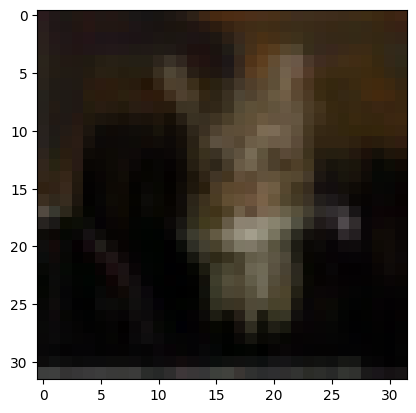

In [44]:
device = "cuda"
image = torch.randn((1, model.config.in_channels, model.config.sample_size, model.config.sample_size)).to(device)

scheduler.set_timesteps(num_inference_steps=1000)

for t in scheduler.timesteps:
    with torch.no_grad():
        noisy_residual = model(image, t).sample

    image = scheduler.step(noisy_residual, t, image).prev_sample

# Visualization
image = (image / 2 + 0.5).clamp(0, 1)
image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
plt.imshow(image)
plt.show()

Now that the diffusion model works we can try to implement the RED-diff pipeline from red_diff.py

## RED-diff

RED-diff code from repo to freely modify here:

In [118]:
cfg = {}
cfg["lr"] = 0.1
cfg["sigma_x0"] = 0.01
cfg["grad_term_weight"] = 0.75
cfg["obs_weight"] = 0.5

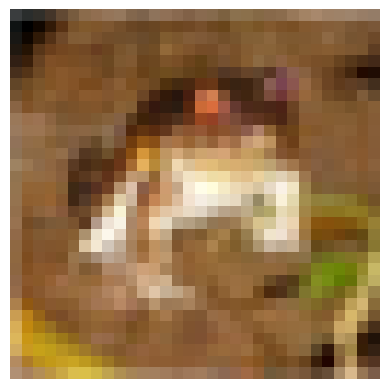

In [70]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),               # [0, 1]
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

img_cifar, label = dataset[0]
y_true = img_cifar.unsqueeze(0).to("cuda")

def show_tensor(tensor):
    img = (tensor.clamp(-1, 1) + 1) / 2
    img = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_tensor(y_true)

In [54]:
# class OPERATOR:
#   def __init__(self):
#     pass

#   def H(self, x):
#     return x

#   def H_pinv(self, x):
#     return x

# H = OPERATOR()

In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GeneralOperator(nn.Module):
    def __init__(self, operator_type='inpainting', channels=3, scale_factor=2):
        super().__init__()
        self.type = operator_type
        self.channels = channels
        self.scale_factor = scale_factor

        # Para Inpainting: Guardamos una máscara (se puede actualizar luego)
        self.register_buffer('mask', torch.ones(1, channels, 1, 1))

    def set_mask(self, mask):
        """Define la zona a reconstruir (1 para datos conocidos, 0 para huecos)"""
        self.mask = mask

    def H(self, x):
        """Operador Directo: Aplica la degradación"""
        if self.type == 'inpainting':
            return x * self.mask

        elif self.type == 'super_resolution':
            # Downsampling (Average Pooling)
            return F.interpolate(x, scale_factor=1/self.scale_factor, mode='bicubic', align_corners=False)

        elif self.type == 'blur':
            # Aquí podrías meter tu código original de Gaussian Blur
            pass

    def H_pinv(self, x):
        """Operador Adjunto (H^T): Proyecta del espacio degradado al espacio de la imagen"""
        if self.type == 'inpainting':
            # El adjunto de una máscara binaria es la misma máscara
            return x * self.mask

        elif self.type == 'super_resolution':
            # Upsampling (el adjunto del downsampling suele ser interpolación)
            return F.interpolate(x, scale_factor=self.scale_factor, mode='bicubic', align_corners=False)

    def forward(self, x):
        return self.H(x)


In [48]:
scheduler.set_timesteps(num_inference_steps=1000)
ts = list(reversed(scheduler.timesteps))

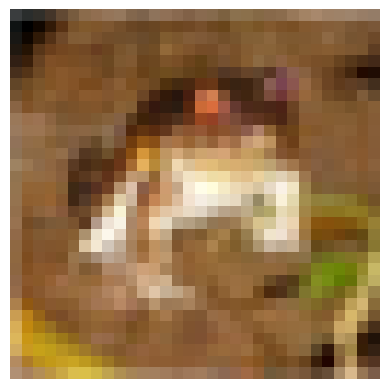

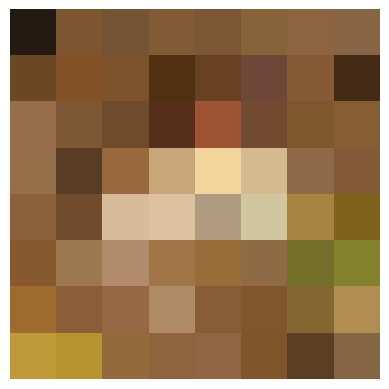

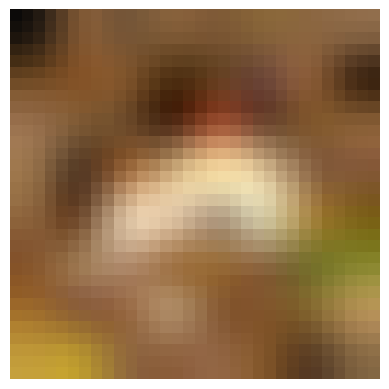

In [113]:
# # Usage Example:
op = GeneralOperator(operator_type="super_resolution").to(device)
y = op.H(op.H(y_true))        # Simulate blurry image
x_hat = op.H_pinv(op.H_pinv(y))         # Crude initial reconstruction

show_tensor(y_true)
show_tensor(y)
show_tensor(x_hat)

100%|██████████| 1000/1000 [00:23<00:00, 43.19it/s]


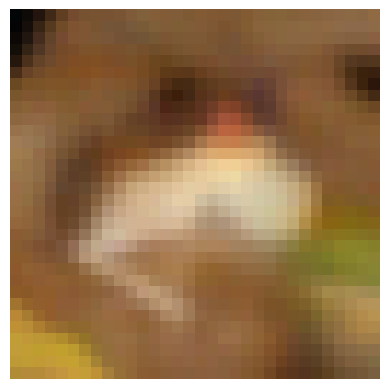

In [119]:
import tqdm

n = 1 # Provisional

H = GeneralOperator(operator_type="super_resolution").to(device)
y_target = H.H(H.H(y_true))

mu = H.H_pinv(H.H_pinv(y_target)).clone().detach().requires_grad_(True)
mu.to(device)
optimizer = torch.optim.Adam([mu], lr=cfg['lr'], betas=(0.9, 0.99))

ss = [-1] + list(ts[:-1])

for ti, si in tqdm.tqdm(zip(reversed(ts), reversed(ss)),total=1000):
    t = torch.full((n,), ti, device=mu.device, dtype=torch.long)

    # Modidied to quickly match cifar10-32
    alpha_t = scheduler.alphas_cumprod[t].view(-1, 1, 1, 1).to(mu.device)

    noise_x0 = torch.randn_like(mu)
    noise_xt = torch.randn_like(mu)

    # Diffusion process
    x0_pred_noisy = mu + cfg['sigma_x0'] * noise_x0
    xt = alpha_t.sqrt() * x0_pred_noisy + (1 - alpha_t).sqrt() * noise_xt

    # Score estimation
    et = model(xt, t).sample
    et = et.detach()

    # Observation loss: ||y_target - H(mu)||²
    loss_obs = torch.nn.functional.mse_loss(H.H(H.H(mu)), y_target) / 2

    # RED regularization: <(et - noise_xt), x0>
    loss_noise = torch.mul((et - noise_xt).detach(), x0_pred_noisy).mean()

    # SNR weighting
    snr_inv = ((1-alpha_t)/alpha_t).sqrt().mean()
    w_t = cfg['grad_term_weight'] * snr_inv

    # Final loss
    loss = w_t * loss_noise + cfg['obs_weight'] * loss_obs

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

show_tensor(mu.detach())

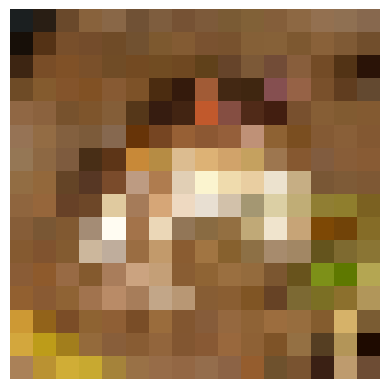

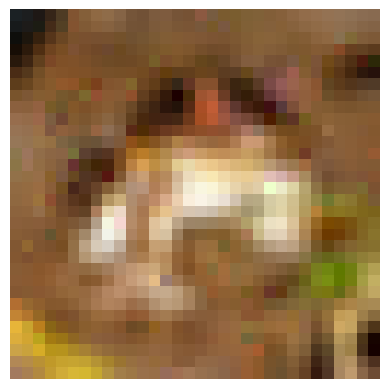

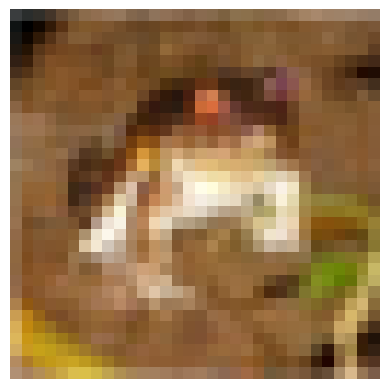

In [103]:
show_tensor(y_target)
show_tensor(mu.detach())
show_tensor(y_true)